# Introduction to Kalmand and Particle filters for Object Tracking


Object tracking is a crucial task in computer vision and robotics. Imagine following an object in a video stream or predicting the path of an airplane. This is challenging as sensors, such as camera or GPS, are often noisy or incomplete. One way to get a better estimate of the object's state, like its position and velocity, is to combine these uncertain measurements. This is where filtering plays its role. Filters are mathematical tools that help to estimate hidden state of a system based on a sequence of noisy inputs. Here we present a few fundamental filtering techniques.

## State estimation

The state of an object is a set of variables that describe its condition at a particular time step. For a moving object, the state might have following elements:

*   **Position** - Where is the object, e.g. x, y coordinates
*   **Velocity** - How fast and in what direction the object is moving, e.g. vx, vy
*   **Acceleration** - Is the object speeding up or slowing down, e.g. ax, ay

The goal of object tracking is **state estimation**, that is estimating the most likely values for these state variables, even though they cannot be measured directly and precisely.

## 1. The G-H Filter (Alpha-Beta Filter)

The g-h filter is one of the simplest filtering algorithms. It introduces the core idea of prediction and correction that can be found in more advanced techniques.

Let's take a moving train on a straight track as an example. We only care about its position and velocity. The algorithm can be expressed as foolows:

1.  **Predict** - Based on the last known posittion and velocity, predict where the train will be next.
    *   `pred_pos = last_pos + (last_vel * time_step)`
    *   `pred_vel = last_vet` (assuming constant velocity for simplicity)
2.  **Measure** - Get a new measurement of the train's position, e.g. from a sensor. This measurement will introduce some noise.
3.  **Update** - Compare the predicted position with the measured position. The difference is the error. Use this error to correct both the position and velocity esimates.
    *   The `g` parameter controls how much we adjust the position based on the measurement error.
    *   The `h` parameter control how much we adjust the velocity based on the measurement error.
    *   `corr_pos = pred_pos + g * (m_pos - pred_pos)`
    *   `corr_vel = pred_vel + h * (m_pos - pred_pos) / time_step`

The g-h filter works well in simple scenarios but relies heavily on correctly set 'g' and 'h' parameters. Additionally, it assumes a relatively simple motion model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def gh_filter(data, x0, dx, g, h, dt):
    x_est = x0
    dx_est = dx
    estimates = []

    for z in data:
        # Prediction step
        x_pred = x_est + (dx_est * dt)
        dx_pred = dx_est

        # Update step
        residual = z - x_pred
        dx_est = dx_pred + h * (residual / dt)
        x_est = x_pred + g * residual

        estimates.append(x_est)

    return np.array(estimates)

In [3]:
# True state
true_velocity = 2.0
initial_pos = 0.0
dt = 1.0 # time step
num_steps = 20
time = np.arange(0, num_steps*dt, dt)
true_positions = initial_pos + true_velocity * time

In [4]:
# Measurements (true position + noise)
measurement_noise_std = 5.0
measurements = true_positions + np.random.normal(0, measurement_noise_std, size=num_steps)

In [5]:
g = 0.2 # Position adjustment factor
h = 0.02 # Velocity adjustment factor

# Initial guesses
initial_pos_guess = measurements[0]
initial_vel_guess = 0.0

estimated_positions = gh_filter(
    data=measurements,
    x0=initial_pos_guess,
    dx=initial_vel_guess,
    g=g,
    h=h,
    dt=dt
)

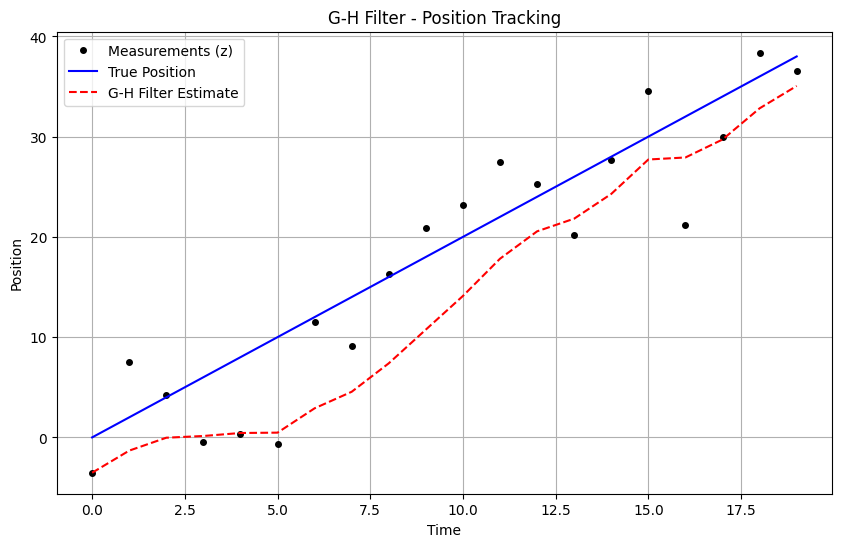

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(time, measurements, 'ko', markersize=4, label='Measurements (z)')
plt.plot(time, true_positions, 'b-', label='True Position')
plt.plot(time, estimated_positions, 'r--', label='G-H Filter Estimate')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('G-H Filter - Position Tracking')
plt.legend()
plt.grid(True)

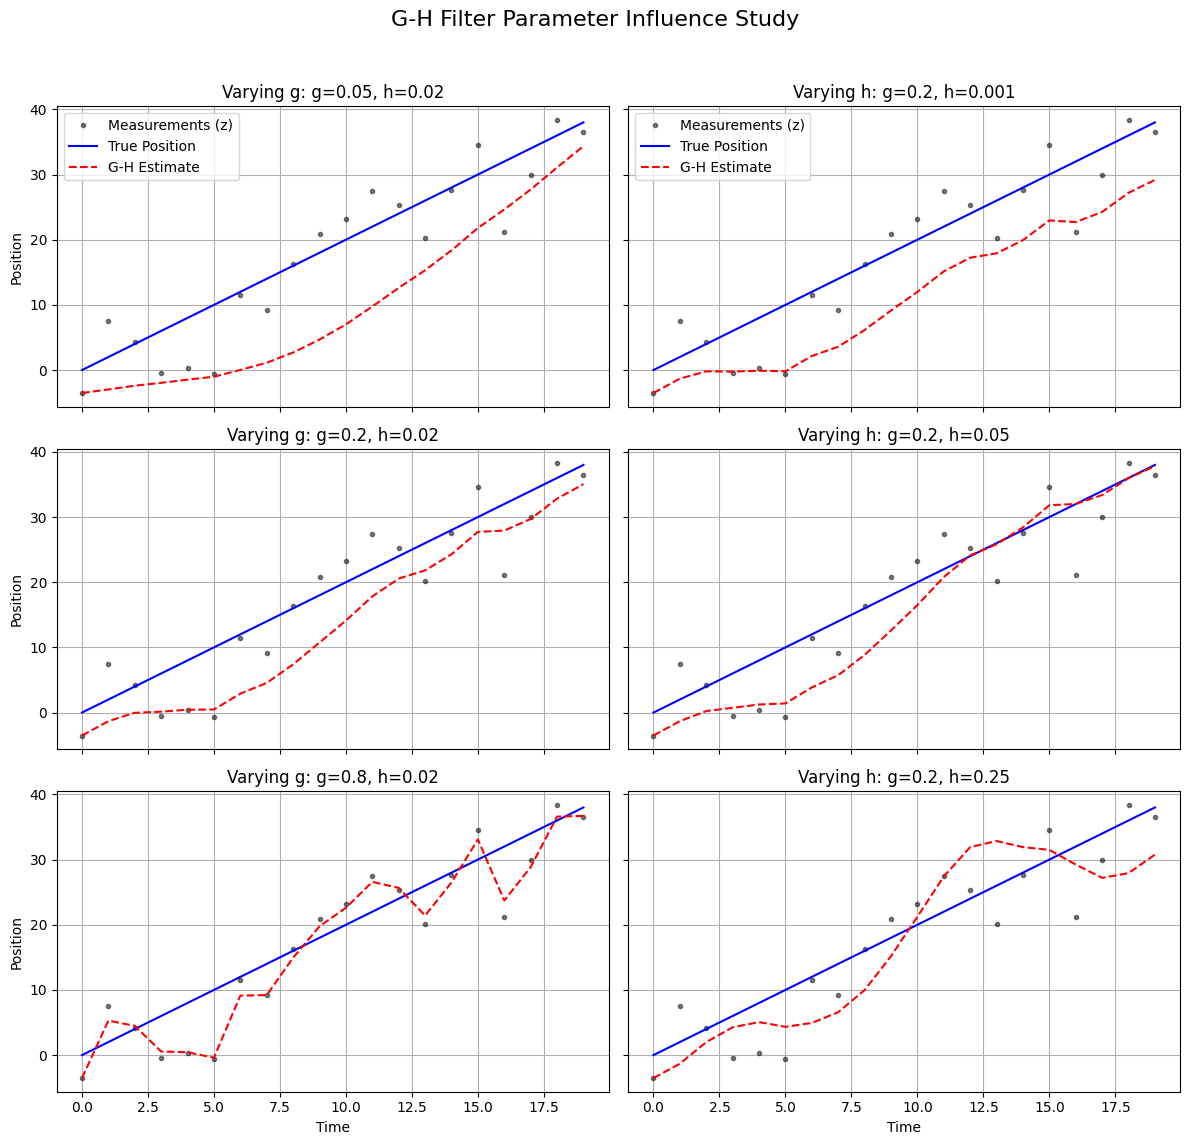

In [7]:
g_values = [0.05, 0.2, 0.8]  # Low, Medium, High g
h_values = [0.001, 0.05, 0.25] # Low, Medium, High h

fixed_g = 0.2  # Use medium g when varying h
fixed_h = 0.02 # Use medium h when varying g

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('G-H Filter Parameter Influence Study', fontsize=16)

# Column 1: Varying g, fixed h
for i, g_val in enumerate(g_values):
    estimated_positions = gh_filter(
        data=measurements,
        x0=initial_pos_guess,
        dx=initial_vel_guess,
        g=g_val,
        h=fixed_h,
        dt=dt
    )
    ax = axes[i, 0]
    ax.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
    ax.plot(time, true_positions, 'b-', linewidth=1.5, label='True Position')
    ax.plot(time, estimated_positions, 'r--', linewidth=1.5, label='G-H Estimate')
    ax.set_title(f'Varying g: g={g_val}, h={fixed_h}')
    ax.grid(True)
    if i == 0:
        ax.legend()
    if i == 2:
        ax.set_xlabel('Time')
    ax.set_ylabel('Position')


# Column 2: Varying h, fixed g
for i, h_val in enumerate(h_values):
    estimated_positions = gh_filter(
        data=measurements,
        x0=initial_pos_guess,
        dx=initial_vel_guess,
        g=fixed_g,
        h=h_val,
        dt=dt
    )
    ax = axes[i, 1]
    ax.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
    ax.plot(time, true_positions, 'b-', linewidth=1.5, label='True Position')
    ax.plot(time, estimated_positions, 'r--', linewidth=1.5, label='G-H Estimate')
    ax.set_title(f'Varying h: g={fixed_g}, h={h_val}')
    ax.grid(True)
    if i == 0:
        ax.legend()
    if i == 2:
        ax.set_xlabel('Time')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

* Varying g (Column 1):
    *   **Low g** - The estimate is very smooth but lags behind the true position
    *   **Medium g** - A balance between smoothing and responsiveness
    *   **High g** - The estimate follows the measurements very closely

* Varying h (Column 2):
    *   **Low h** - The velocity esimate changes very slowly
    *   **Medium h** - A balanced velocity update
    *   **High h** - The velocity estimate changes rapidly based on position error

## 2. The Discrete Bayes Filter

While the g-h filter gives a single best guess, the bayes filter provides a probabilistic approach. Instead of tracking a single value, it maintains a probability distribution over all possible states.

1.  **Predict** - Take the current probability distribution of the state and predict how it will evolve over time based on how we think the object moves.
2.  **Update** - Use the latest measurement to update the predicted probability distribution. States that are more consistent with the measurements become more likely, while inconsistent states become less likely.

The Discrete Bayes Filter is a specific algorithm where the state space is divided into finite number of bins or grid cells. It maintains the probability if the object in each cell. This can represent arbitraty probability distributions, however, it can become computationally expensive if the state space is large (curse of dimensionality).

In [8]:
def predict(belief, kernel):
    return np.convolve(belief, kernel, mode='same')

def update(belief, measurement, likelihood_fn):
    likelihood = likelihood_fn(measurement, np.arange(len(belief)))
    posterior_unnormalized = belief * likelihood

    # Normalize the posterior distribution
    norm = np.sum(posterior_unnormalized)
    if norm > 1e-9: # Avoid division by zero
        return posterior_unnormalized / norm
    else:
        return posterior_unnormalized

def compute_likelihood(measurement, states, z_prob):
    """
    Simplified likelihood calculation for each possible state.
    """
    N = len(states)
    likelihood = np.zeros(N)
    for x in states:
        # Calculate distance in circular world
        diff = abs(measurement - x)
        dist = min(diff, N - diff)

        if dist == 0:
            likelihood[x] = z_prob
        elif dist == 1:
             likelihood[x] = (1.0-z_prob)/2.0  # Simplified: only adjacent noise
        else:
             likelihood[x] = 0.0  # Simplified: zero probability elsewhere

    return likelihood

In [9]:
world_size = 20         # Number of discrete locations/states
num_steps = 50          # Number of simulation steps
initial_pos = 5         # True starting position
move_step = 1 

In [10]:
move_kernel = np.array([0.1, 0.8, 0.1])  # 10 % chance to move left, 80 % chance to stay, 10 % chance to move right

In [11]:
measurement_correct_prob = 0.7

In [12]:
belief = np.ones(world_size) / world_size  # uniform probability
true_state = initial_pos

belief_history = [belief]
true_state_history = [true_state]
measurement_history = []

In [13]:
for t in range(num_steps):
    # 1. Simulate True Movement
    move_options = [-1, 0, 1] # Relative moves possible
    actual_move = np.random.choice(move_options, p=move_kernel)
    true_state = (true_state + actual_move) % world_size # Circular world
    true_state_history.append(true_state)

    # 2. Simulate Measurement
    measurement_likelihoods = compute_likelihood(true_state, np.arange(world_size), measurement_correct_prob)
    # Sample a measurement based on these likelihoods
    measurement_likelihoods_norm = measurement_likelihoods / np.sum(measurement_likelihoods)
    if np.sum(measurement_likelihoods) < 1e-9:
         measurement = true_state
    else:
        measurement = np.random.choice(np.arange(world_size), p=measurement_likelihoods_norm)

    measurement_history.append(measurement)

    # 3. Predict Step
    belief_prior = predict(belief, move_kernel)

    # 4. Update Step
    belief = update(belief_prior, measurement,
                    lambda z, states: compute_likelihood(z, states, measurement_correct_prob))

    belief_history.append(belief)

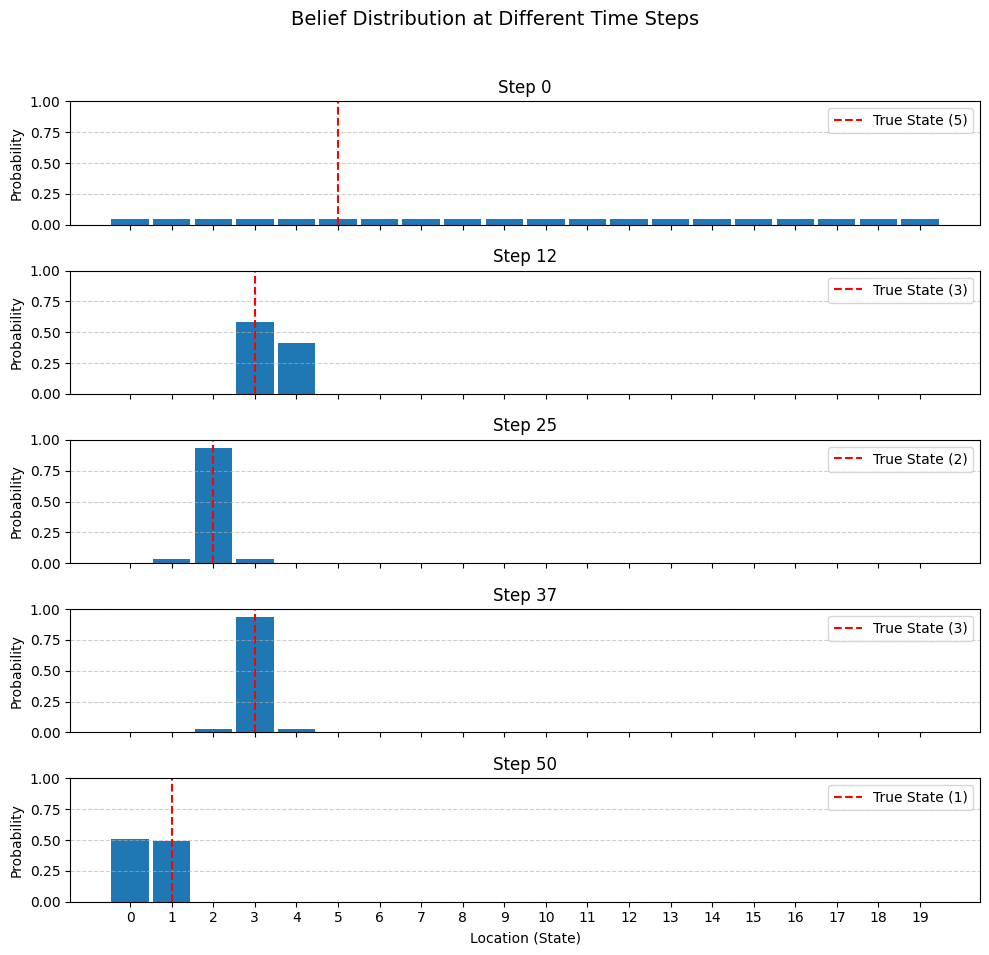

In [14]:
steps_to_plot = [0, num_steps // 4, num_steps // 2, 3 * num_steps // 4, num_steps]

fig_hist, axes_hist = plt.subplots(len(steps_to_plot), 1, figsize=(10, 2 * len(steps_to_plot)), sharex=True)
fig_hist.suptitle('Belief Distribution at Different Time Steps', fontsize=14)

for i, step in enumerate(steps_to_plot):
    ax = axes_hist[i]
    belief_at_step = belief_history[step]
    true_state_at_step = true_state_history[step]

    ax.bar(np.arange(world_size), belief_at_step, width=0.9)
    ax.axvline(true_state_at_step, color='r', linestyle='--', label=f'True State ({true_state_at_step})')
    ax.set_title(f'Step {step}')
    ax.set_ylabel('Probability')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.0)


axes_hist[-1].set_xlabel('Location (State)')
plt.xticks(np.arange(world_size))
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## 3. The Kalman Filter

The Kalman filter like the g-f filter operates in a predict-correct cycle, but it takes a more rigorous, probabilistic approach derived from the general Bayes filter framework (similar to the Discrete Bayes filter). It is an optimal filter if certain assumptions hold:

*   **Linearity** - The system dynamics and the measurements process can be described by linear equations
*   **Gaussian noise** - The noise in the system dynamics and the measurements follows a Gaussian distribution (bell-curve)

The Kalman filter works in two steps (like the Bayes filter):

1.  **Predict** - Predict the next state and its uncertainty, represented as a Gaussian distribution, based on the current estimate and the system model. The prediction generally increases the uncertainty (bell curve gets wider).
2.  **Update** - Use the current measurement (with Gaussian noise) to correct the predicted state. The update combines the predicted state and the measurement distributions to get a more precise state estimation. The Kalman Gain, that determines the trust in the prediction vs measurement, plays a similar role to the fixed `g` and `h` parameters in the g-h filter, but it dynamically adjusts based on the estimated uncertainty.

Kalman filter, compared to the Discrete Bayes filter, uses a continuous Gaussian distribution. This makes it computationally efficient but restricted to problems where the linear-Gaussian assumptions hold. If the real system violates these assumptions, the filter's performance can degrade significantly.



In [15]:
%%bash
pip install filterpy

### Position Tracking - 1D Constant Velocity

In [16]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

In [17]:
dt = 1.0           # Time step
num_steps = 50     # Number of simulation steps
true_initial_pos = 0.0
true_velocity = 2.0
process_noise_std = 0.1  # Std dev of process noise (unmodeled acceleration)
measurement_noise_std = 5.0 # Std dev of measurement noise

In [18]:
true_positions = np.zeros(num_steps)
true_velocities = np.zeros(num_steps)
true_positions[0] = true_initial_pos
true_velocities[0] = true_velocity

In [19]:
for t in range(1, num_steps):
    # Add some random acceleration (process noise) to true velocity
    true_velocities[t] = true_velocities[t-1] + np.random.normal(0, process_noise_std)
    true_positions[t] = true_positions[t-1] + true_velocities[t-1] * dt # Use previous velocity for position update

# Measurements (true position + measurement noise)
measurements = true_positions + np.random.normal(0, measurement_noise_std, size=num_steps)

In [20]:
kf = KalmanFilter(dim_x=2, dim_z=1)                 # State vector x = [pos, vel], Measurement vector z = [pos]
kf.F = np.array([[1., dt],                          # State transition Matrix - how the state evolves without noise
                 [0., 1.]])
kf.H = np.array([[1., 0.]])                         # Measurement Function - maps state vetor to measurement vector
kf.R = np.array([[measurement_noise_std**2]])       # Measurement Noise Covariance - variance of the measurement noise
kf.Q = Q_discrete_white_noise(dim=2,                # Process Noise Covariance - uncertainty in the motion model (unmodeled accelearation)
                              dt=dt, 
                              var=process_noise_std**2)
kf.x = np.array([[measurements[0]],                 # Initial State Estimate - use the first measurement for position, assume 0 velocity
                 [0.]])
kf.P = np.array([[measurement_noise_std**2, 0.],    # Initial State Covariance - initial uncertainty about the state, high in position and velocity
                 [0.,                  1000.]]) 


In [21]:
filtered_states = []
state_covariances = []

for z in measurements:
    # Predict step
    kf.predict()

    # Update step
    kf.update(z)

    # Store results
    filtered_states.append(kf.x.copy())
    state_covariances.append(kf.P.copy())

In [22]:
filtered_states = np.array(filtered_states).squeeze() # Remove single dimensions
state_covariances = np.array(state_covariances)

# Extract estimated positions, velocities, and uncertainty
estimated_positions = filtered_states[:, 0]
pos_uncertainty = np.sqrt(state_covariances[:, 0, 0])

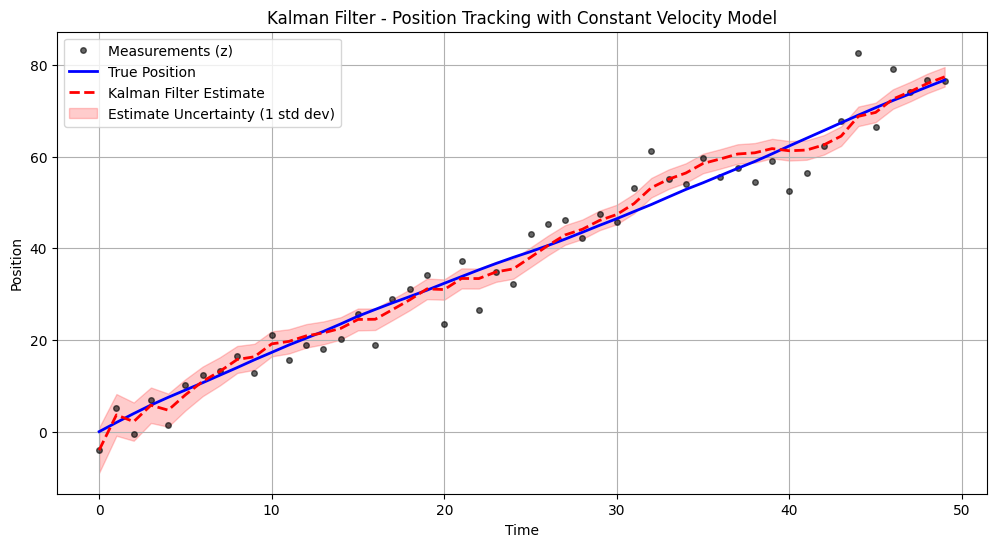

In [23]:
time = np.arange(num_steps) * dt

plt.figure(figsize=(12, 6))
plt.plot(time, measurements, 'ko', markersize=4, alpha=0.6, label='Measurements (z)')
plt.plot(time, true_positions, 'b-', linewidth=2, label='True Position')
plt.plot(time, estimated_positions, 'r--', linewidth=2, label='Kalman Filter Estimate')
plt.fill_between(time, estimated_positions - pos_uncertainty,
                 estimated_positions + pos_uncertainty, color='r', alpha=0.2, label='Estimate Uncertainty (1 std dev)')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Kalman Filter - Position Tracking with Constant Velocity Model')
plt.legend()
plt.grid(True)
plt.show()

### Position Tracking - 1D with Acceleration

In [24]:
true_initial_pos = 0.0
true_initial_vel = 0.0
true_initial_acc = 1.0
process_noise_std = 0.25
measurement_noise_std = 5.0

In [25]:
true_positions = np.zeros(num_steps)
true_velocities = np.zeros(num_steps)
true_accelerations = np.zeros(num_steps)

true_positions[0] = true_initial_pos
true_velocities[0] = true_initial_vel
true_accelerations[0] = true_initial_acc

for t in range(1, num_steps):
    # Add some random process noise
    process_noise = np.random.normal(0, process_noise_std)

    # Change acceleration profile partway through
    if 10 <= t < 30:
        true_accelerations[t] = true_accelerations[t-1] + process_noise
    elif t >= 30:
         true_accelerations[t] = -1.0 + process_noise # Decelerate
    else:
        true_accelerations[t] = true_accelerations[t-1] + process_noise

    # Update state based on previous state using physics equations
    true_velocities[t] = true_velocities[t-1] + true_accelerations[t-1] * dt
    true_positions[t] = true_positions[t-1] + true_velocities[t-1] * dt + 0.5 * true_accelerations[t-1] * dt**2

# Measurements (true position + measurement noise)
measurements = true_positions + np.random.normal(0, measurement_noise_std, size=num_steps)

In [26]:
kf = KalmanFilter(dim_x=3, dim_z=1)                                     # x = [pos, vel, acc], z = [pos]
kf.F = np.array([[1., dt, 0.5*dt**2],                                   
                 [0., 1., dt       ],
                 [0., 0., 1.       ]])
kf.H = np.array([[1., 0., 0.]])  
kf.R = np.array([[measurement_noise_std**2]])              
kf.Q = Q_discrete_white_noise(dim=3, dt=dt, var=process_noise_std**2)
kf.x = np.array([[measurements[0]],
                 [0.],
                 [0.]]) # Guess zero initial acceleration
kf.P = np.diag([measurement_noise_std**2, 100., 10.])

In [27]:
filtered_states = []
state_covariances = []

for z in measurements:
    # Predict step
    kf.predict()

    # Update step
    kf.update(z)

    # Store results
    filtered_states.append(kf.x.copy())
    state_covariances.append(kf.P.copy())

In [28]:
filtered_states = np.array(filtered_states).squeeze()
state_covariances = np.array(state_covariances)

# Extract estimated states and uncertainty
estimated_positions = filtered_states[:, 0]
estimated_velocities = filtered_states[:, 1]
estimated_accelerations = filtered_states[:, 2]

pos_uncertainty = np.sqrt(state_covariances[:, 0, 0])
vel_uncertainty = np.sqrt(state_covariances[:, 1, 1])
acc_uncertainty = np.sqrt(state_covariances[:, 2, 2])

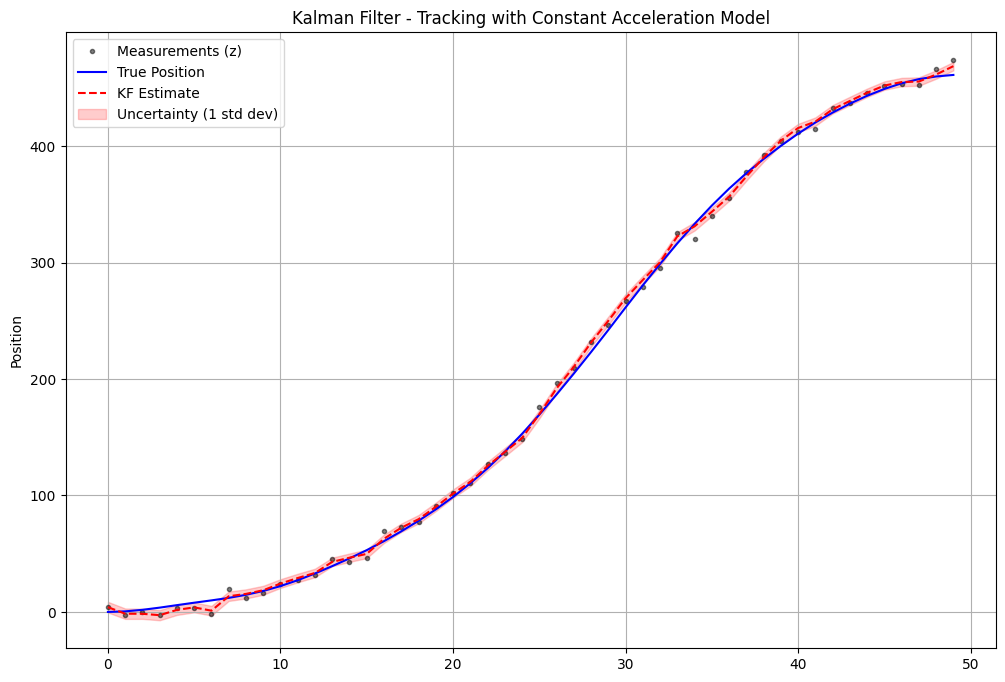

In [29]:
time = np.arange(num_steps) * dt

plt.figure(figsize=(12, 8))
plt.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
plt.plot(time, true_positions, 'b-', linewidth=1.5, label='True Position')
plt.plot(time, estimated_positions, 'r--', linewidth=1.5, label='KF Estimate')
plt.fill_between(time, estimated_positions - pos_uncertainty,
                 estimated_positions + pos_uncertainty, color='r', alpha=0.2, label='Uncertainty (1 std dev)')
plt.ylabel('Position')
plt.title('Kalman Filter - Tracking with Constant Acceleration Model')
plt.legend()
plt.grid(True)

## The Particle Filter (Sequential Monte Carlo)

Particle filters are part of the Sequential Monte Carlo (SMC) algorithms and represent the probability distribution using a set of random samples known as particles. Each particle represents a specific hypothesis about the object's state, such as a possible position and velocity. While the Discrete Bayes filter discretizes the state space into a grid, the Particle Filter uses set of random samples to approximate the probability distribution. This sampling method avoids the curse of dimensionality. Like the Discrete Bayes and Kalman filters, the Particle Filter consists of the predict-update cycle.

1. **Initialization** - Start with a cloud of particles representing the initial belief about the state distribution.
2. **Predict** - Move each particle according to the system dynamics model, adding random noise. This shifts the particle cloud to where we expect the object to be next. This step is analogous to the prediction step in Kalman or Discrete Bayes filters, but applied to each sample individually.
3. **Update (Weighting)** - Assign a weight to each particle based on how well its state hypothesis matches the latest measurements. Particles whose states are more consistent with the measurement get higher weights.
4. **Resampling** - Generate a new set of particles by sampling from the current set, where particles with higher weights are more likely to be selected and duplicated, while particles with low weights are likely to be discarded. This focuses the particles on the most probable regions of the state space. 

The weighting and resampling steps together are the particle filter's way of applying the Bayesian update. Unlike the Kalman fitler that requires linear models and Gaussian noise assumptions, the particle filter's strength lies in its ability to handle non-linear dynamics and arbitrary noise distributions, simply by how particles are propagated and weighted. However, particle filters are more computationally expensive than Kalman filters, especially if many particles are needed. Additionally, improperly tuned filter can suffer from "particle degeneracy" where most particles have negligible weights.

### 1D Constant Velocity

In [30]:
from scipy.stats import norm
from filterpy.monte_carlo import systematic_resample

In [31]:
dt = 1.0
num_steps = 50
true_initial_pos = 0.0
true_velocity = 1.0
process_noise_std = 0.5
measurement_noise_std = 2.0

In [32]:
true_positions = np.zeros(num_steps)
true_positions[0] = true_initial_pos

In [33]:
for t in range(1, num_steps):
    process_noise = np.random.normal(0, process_noise_std)
    true_positions[t] = true_positions[t-1] + true_velocity * dt + process_noise

measurements = true_positions + np.random.normal(0, measurement_noise_std, size=num_steps)

In [34]:
# Particle Filter initialization
N_particles = 1000
particles = np.random.normal(measurements[0], measurement_noise_std*2, size=N_particles)
weights = np.ones(N_particles) / N_particles

In [35]:
estimated_positions = np.zeros(num_steps)
particle_history = []

In [36]:
for t in range(num_steps):
    # Predict
    process_noise_sample = np.random.normal(0, process_noise_std, size=N_particles)
    particles += true_velocity * dt + process_noise_sample

    # Update (Weighting)
    likelihoods = norm(particles, measurement_noise_std).pdf(measurements[t])

    # Update weights: weight = prior_weight * likelihood
    weights *= likelihoods

    # Normalize weights
    weights_sum = np.sum(weights)
    if weights_sum < 1e-100:
        print(f"Warning: Sum of weights near zero at step {t}. Re-initializing weights uniformly.")
        weights.fill(1.0 / N_particles)
    else:
        weights /= weights_sum

    # Resampling
    indices = systematic_resample(weights)
    particles[:] = particles[indices]
    weights.fill(1.0 / N_particles)

    # Estimation
    estimated_positions[t] = np.mean(particles)

    if t % 10 == 0 or t == num_steps - 1: # Store every 10 steps + last step
         particle_history.append((t, particles.copy()))

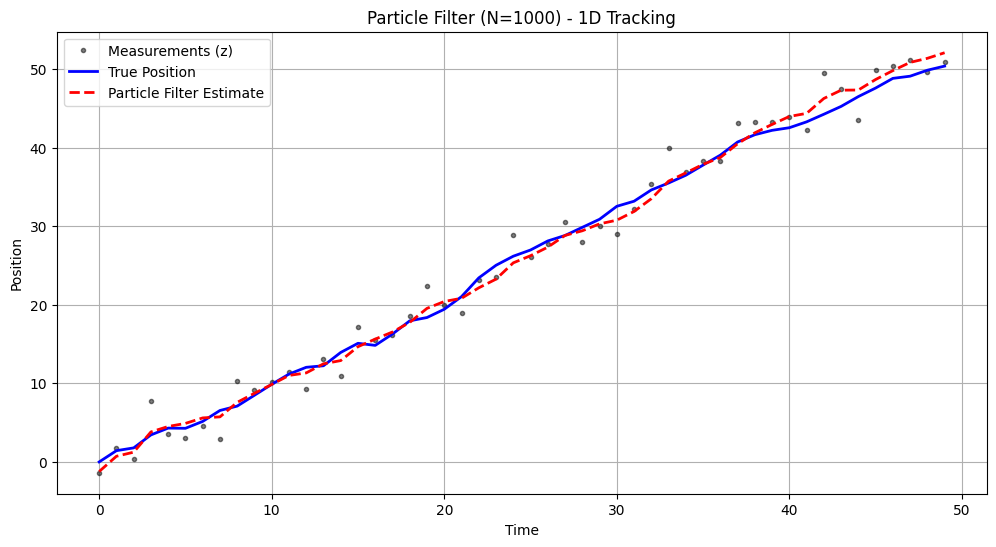

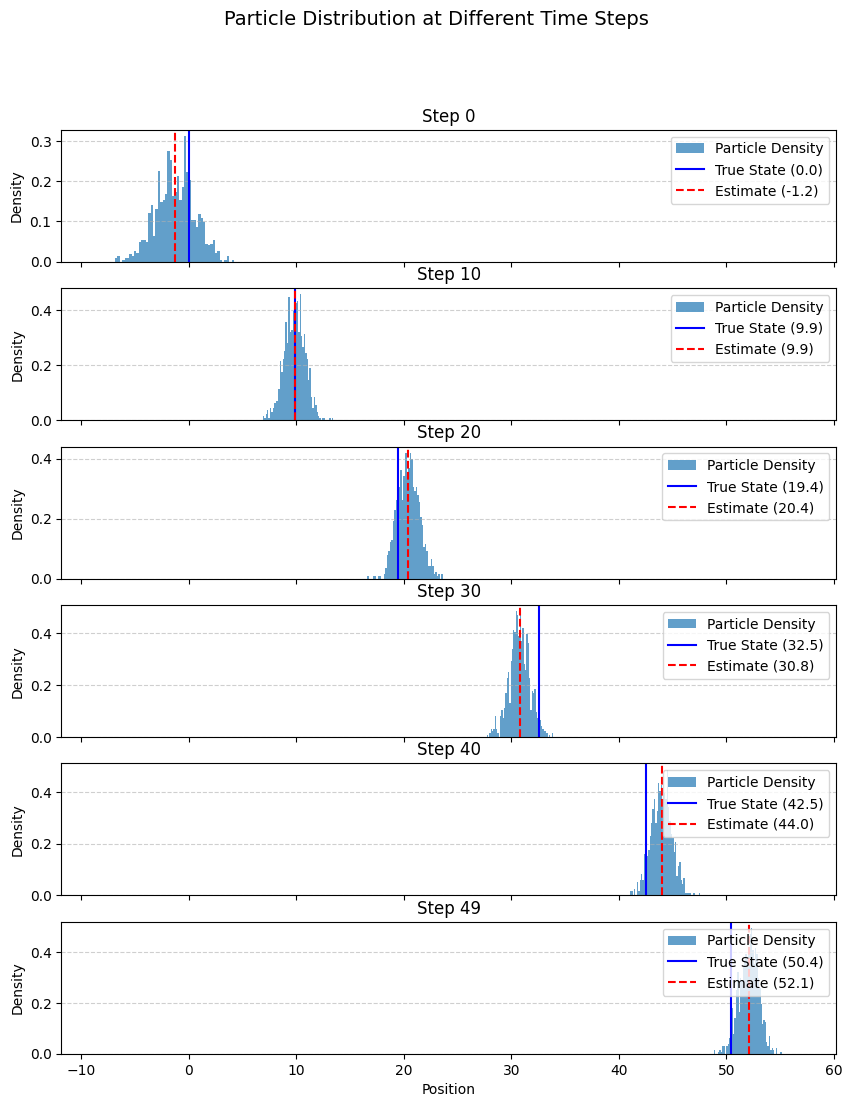

In [37]:
time = np.arange(num_steps) * dt

# Plot Position Tracking
plt.figure(figsize=(12, 6))
plt.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
plt.plot(time, true_positions, 'b-', linewidth=2, label='True Position')
plt.plot(time, estimated_positions, 'r--', linewidth=2, label='Particle Filter Estimate')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title(f'Particle Filter (N={N_particles}) - 1D Tracking')
plt.legend()
plt.grid(True)
plt.show()

# Plot Particle Distribution at Selected Steps
num_hist_plots = len(particle_history)
fig_hist, axes_hist = plt.subplots(num_hist_plots, 1, figsize=(10, 2 * num_hist_plots), sharex=True)

fig_hist.suptitle('Particle Distribution at Different Time Steps', fontsize=14)
overall_min = min(p.min() for _, p in particle_history)
overall_max = max(p.max() for _, p in particle_history)

for i, (step, particles_at_step) in enumerate(particle_history):
    ax = axes_hist[i]
    true_state_at_step = true_positions[step]

    ax.hist(particles_at_step, bins=50, density=True, alpha=0.7, label='Particle Density')
    ax.axvline(true_state_at_step, color='b', linestyle='-', label=f'True State ({true_state_at_step:.1f})')
    ax.axvline(estimated_positions[step], color='r', linestyle='--', label=f'Estimate ({estimated_positions[step]:.1f})')

    ax.set_title(f'Step {step}')
    ax.set_ylabel('Density')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_xlim(overall_min - 5, overall_max + 5)

axes_hist[-1].set_xlabel('Position')
plt.show()

### 1D with Accleration

In [38]:
true_initial_pos = 0.0
true_initial_vel = 0.0
true_initial_acc = 1.0
process_noise_std = 0.25
measurement_noise_std = 5.0

In [39]:
true_positions = np.zeros(num_steps)
true_velocities = np.zeros(num_steps)
true_accelerations = np.zeros(num_steps)

true_positions[0] = true_initial_pos
true_velocities[0] = true_initial_vel
true_accelerations[0] = true_initial_acc

for t in range(1, num_steps):
    # Add some random process noise
    process_noise = np.random.normal(0, process_noise_std)

    # Change acceleration profile partway through
    if 10 <= t < 30:
        true_accelerations[t] = true_accelerations[t-1] + process_noise
    elif t >= 30:
         true_accelerations[t] = -1.0 + process_noise # Decelerate
    else:
        true_accelerations[t] = true_accelerations[t-1] + process_noise

    # Update state based on previous state using physics equations
    true_velocities[t] = true_velocities[t-1] + true_accelerations[t-1] * dt
    true_positions[t] = true_positions[t-1] + true_velocities[t-1] * dt + 0.5 * true_accelerations[t-1] * dt**2 + process_noise

# Measurements (true position + measurement noise)
measurements = true_positions + np.random.normal(0, measurement_noise_std, size=num_steps)

In [40]:
# Particle Filter initialization
N_particles = 2000
# Particles represent [position, velocity, acceleration]
particles = np.zeros((N_particles, 3))
particles[:, 0] = np.random.normal(measurements[0], measurement_noise_std*2, size=N_particles)
particles[:, 1] = np.random.normal(0, 1.0, size=N_particles)
particles[:, 2] = np.random.normal(0, 0.5, size=N_particles)
weights = np.ones(N_particles) / N_particles

In [41]:
estimated_positions = np.zeros(num_steps)
particle_history = []

In [42]:
for t in range(num_steps):
    pos = particles[:, 0]
    vel = particles[:, 1]
    acc = particles[:, 2]

    # Predict
    acc_noise = np.random.normal(0, process_noise_std, size=N_particles)
    acc_pred = acc + acc_noise
    vel_pred = vel + acc * dt
    pos_pred = pos + vel * dt + 0.5 * acc * dt**2
    
    particles[:, 0] = pos_pred
    particles[:, 1] = vel_pred
    particles[:, 2] = acc_pred

    # Update (Weighting)
    likelihoods = norm(particles[:, 0], measurement_noise_std).pdf(measurements[t])
    weights *= likelihoods
    weights_sum = np.sum(weights)
    if weights_sum < 1e-100:
        print(f"Warning: Sum of weights near zero at step {t}. Re-initializing weights uniformly.")
        weights.fill(1.0 / N_particles)
    else:
        weights /= weights_sum

    # Resampling
    indices = systematic_resample(weights)
    particles[:] = particles[indices]
    weights.fill(1.0 / N_particles)


    # Estimation
    estimated_positions[t] = np.mean(particles[:, 0])

    if t % 10 == 0 or t == num_steps - 1:  # Store every 10 steps + last step
         particle_history.append((t, particles[:, 0].copy()))

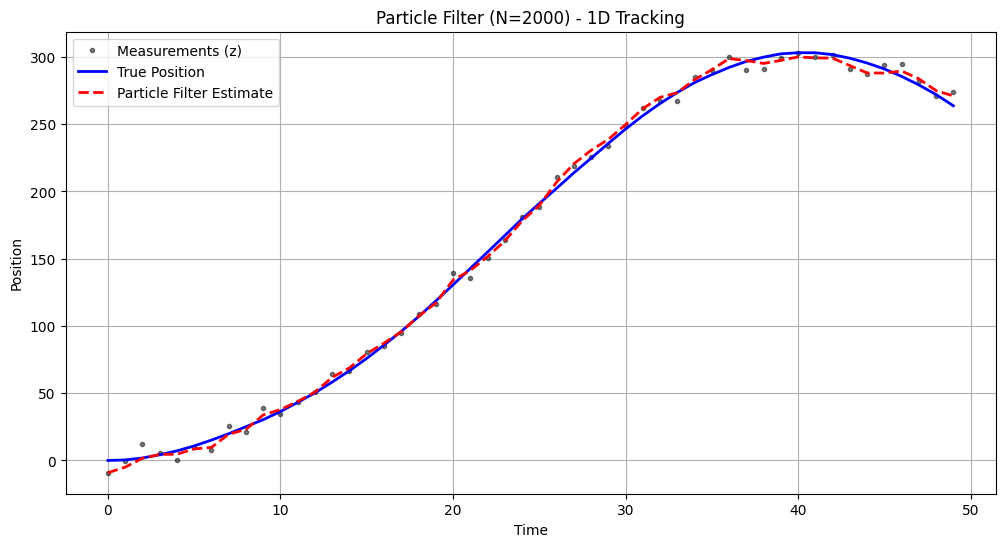

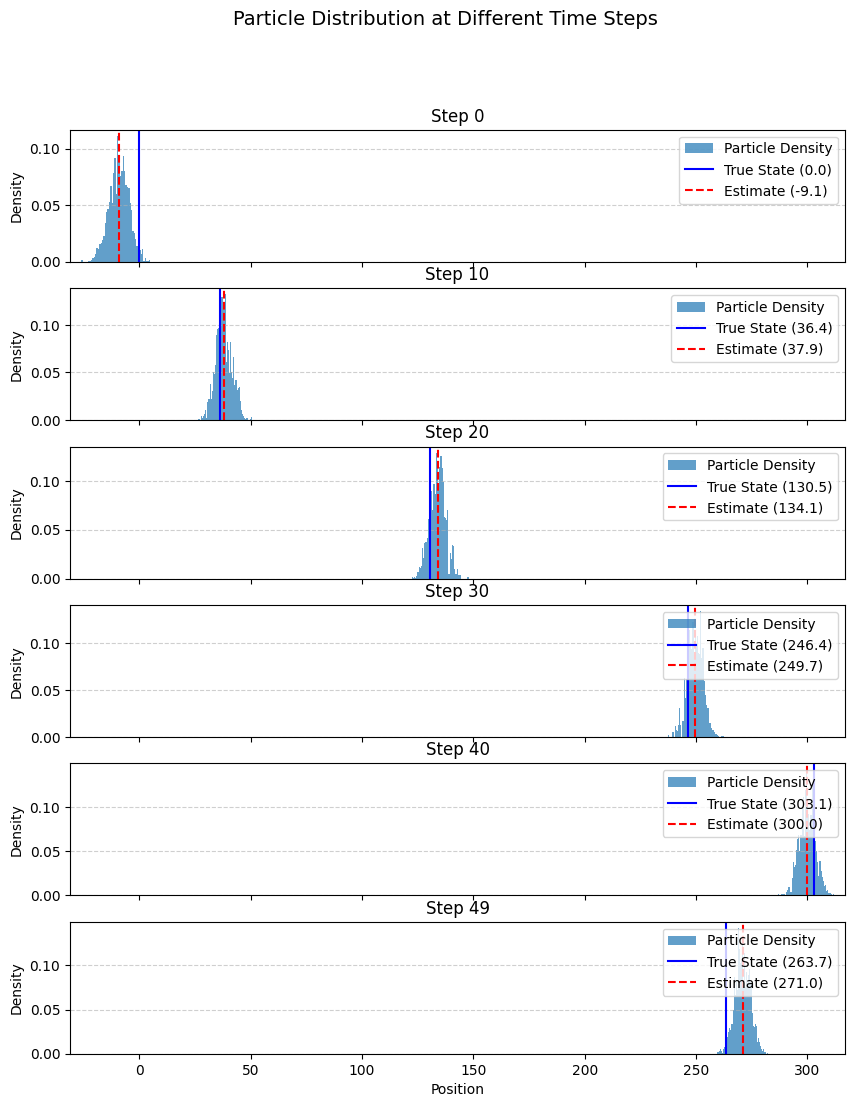

In [43]:
time = np.arange(num_steps) * dt

# Plot Position Tracking
plt.figure(figsize=(12, 6))
plt.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
plt.plot(time, true_positions, 'b-', linewidth=2, label='True Position')
plt.plot(time, estimated_positions, 'r--', linewidth=2, label='Particle Filter Estimate')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title(f'Particle Filter (N={N_particles}) - 1D Tracking')
plt.legend()
plt.grid(True)
plt.show()

# Plot Particle Distribution at Selected Steps
num_hist_plots = len(particle_history)
fig_hist, axes_hist = plt.subplots(num_hist_plots, 1, figsize=(10, 2 * num_hist_plots), sharex=True)

fig_hist.suptitle('Particle Distribution at Different Time Steps', fontsize=14)
overall_min = min(p.min() for _, p in particle_history)
overall_max = max(p.max() for _, p in particle_history)

for i, (step, particles_at_step) in enumerate(particle_history):
    ax = axes_hist[i]
    true_state_at_step = true_positions[step]

    ax.hist(particles_at_step, bins=50, density=True, alpha=0.7, label='Particle Density')
    ax.axvline(true_state_at_step, color='b', linestyle='-', label=f'True State ({true_state_at_step:.1f})')
    ax.axvline(estimated_positions[step], color='r', linestyle='--', label=f'Estimate ({estimated_positions[step]:.1f})')

    ax.set_title(f'Step {step}')
    ax.set_ylabel('Density')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_xlim(overall_min - 5, overall_max + 5)

axes_hist[-1].set_xlabel('Position')
plt.show()

## Resources

1. Kalman and Bayesian Filters in Python - https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python?tab=readme-ov-file